In [13]:
import pandas as pd
import pypowsybl.network as pn
import pypowsybl as pp
from pypowsybl_jupyter import nad_explorer
import re
import networkx as nx
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import builtins
import itertools
import importlib
import utils


from utils import edges_with_impedance, median,cluster_subgraph,network_construction, type_controller, unique_list, plot_slack_cluster, slack_subgraph_2nd, plot_graph, dfs_slack_2nd, slack_subgraph, has_slack, visualize_graph, dfs_with_slack, median 

importlib.reload(utils)

<module 'utils' from 'd:\\dev\\powsybl-open-loadflow-knitro-solver\\utils.py'>

In [14]:
network_name = "test_active_power_and_correction_20_ieee/ieee300/ieee300"
network ="ieee300"

In [15]:
# slack_info 
pertubation = "active-perturbation"
data = pd.read_csv(
    network_name +"_" + pertubation + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
optim_info = pd.read_csv(
    network_name + "_" + pertubation + "_optim_info.csv",
    sep=";",
    engine="python",
    index_col=False,
)
extension_in = '.xiidm'
network = pn.load('./Outputs/' + network +"-"+pertubation + extension_in)
edges = edges_with_impedance(network)

data_grouped = data.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped['Total_slack_abs'] = data_grouped['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
G, dist, pos = network_construction(edges, data_grouped)
clusters = slack_subgraph(G, data_grouped)
data_grouped = cluster_subgraph(G, clusters, data_grouped, dist)
fig = plot_slack_cluster(G, pos, clusters,data_grouped,data, col_centroid='centroid')
fig.show()

Focal bus perturbation VL3_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL3_0_load'])
Focal bus perturbation VL319_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL319_0_load'])
Focal bus perturbation VL526_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL526_0_load'])
Focal bus perturbation VL562_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL562_0_load'])
Focal bus perturbation VL609_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL609_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B92-G'], [nan], [nan], ['VL92_0_load'])
Focal bus perturbation VL92_0 has dominant slac

In [16]:
-391.9002*1.2

-470.28023999999994

In [17]:
# slack_info 
pertubation1 = "1"
data_correction2 = pd.read_csv(
    network_name +"_" + pertubation1 + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
# network = pn.load('./Outputs/' + network_name+"-corrected-"+pertubation1 + extension_in)
new_row = pd.read_csv(network_name+"_"+pertubation1+"_optim_info.csv", sep=";", engine="python", index_col=False)
optim_info = pd.concat([optim_info, new_row], ignore_index=True)
data_grouped_2 = data_correction2.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_2['Total_slack_abs'] = data_grouped_2['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
G_2, dist, pos = network_construction(edges, data_grouped_2)
clusters = slack_subgraph(G_2, data_grouped_2)
data_grouped_2 = cluster_subgraph(G_2, clusters, data_grouped_2, dist)
fig = plot_slack_cluster(G_2, pos, clusters,data_grouped_2,data, col_centroid='centroid')
fig.show()

Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL76_0 has dominant slack V but no suitable controller
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B92-G'], [nan], [nan], ['VL92_0_load'])
Focal bus perturbation VL92_0 has dominant slack V but no suitable controller
Focal bus perturbation VL114_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL114_0_load'])
Focal bus perturba

In [18]:
-7.0084*1.2

-8.410079999999999

In [19]:
# slack_info 
pertubation1 = "2"
data_correction3 = pd.read_csv(
    network_name +"_" + pertubation1 + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
# network = pn.load('./Outputs/' + network_name+"-corrected-"+pertubation1 + extension_in)
new_row = pd.read_csv(network_name+"_"+pertubation1+"_optim_info.csv", sep=";", engine="python", index_col=False)
optim_info = pd.concat([optim_info, new_row], ignore_index=True)
data_grouped_3 = data_correction3.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_3['Total_slack_abs'] = data_grouped_3['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
G_3, dist, pos = network_construction(edges, data_grouped_3)
clusters = slack_subgraph(G_3, data_grouped_3)
data_grouped_3 = cluster_subgraph(G_3, clusters, data_grouped_3, dist)
fig = plot_slack_cluster(G_3, pos, clusters,data_grouped_3,data, col_centroid='centroid')
fig.show()

Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL76_0 has dominant slack V but no suitable controller
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B92-G'], [nan], [nan], ['VL92_0_load'])
Focal bus perturbation VL92_0 has dominant slack V but no suitable controller
Focal bus perturbation VL324_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL324_0_load'])
Focal bus perturba

In [20]:
-2.2652*1.2

-2.71824

In [21]:
# slack_info 
pertubation1 = "3"
data_correction4 = pd.read_csv(
    network_name +"_" + pertubation1 + ".csv",
    sep=";",
    engine="python",
    index_col=False,
   # on_bad_lines="skip",
)
# network = pn.load('./Outputs/' + network_name+"-corrected-"+pertubation1 + extension_in)
new_row = pd.read_csv(network_name+"_"+pertubation1+"_optim_info.csv", sep=";", engine="python", index_col=False)
optim_info = pd.concat([optim_info, new_row], ignore_index=True)
data_grouped_4 = data_correction4.groupby('busId')[['type','slackValue_pu','slackValue','gen','controlevoltage','transfo','shunt','load','info']].agg(unique_list)
data_grouped_4['Total_slack_abs'] = data_grouped_4['slackValue_pu'].apply(lambda x: builtins.sum(abs(slack) for slack in x) if isinstance(x, list) else abs(x))
G_4, dist, pos = network_construction(edges, data_grouped_4)
clusters = slack_subgraph(G_4, data_grouped_4)
data_grouped_4 = cluster_subgraph(G_4, clusters, data_grouped_4, dist)
fig = plot_slack_cluster(G_4, pos, clusters,data_grouped_4,data, col_centroid='centroid')
fig.show()

Focal bus perturbation VL76_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL76_0', controllerElements=[VL76_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B76-G'], [nan], [nan], ['VL76_0_load'])
Focal bus perturbation VL76_0 has dominant slack V but no suitable controller
Focal bus perturbation VL528_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL528_0_load'])
Focal bus perturbation VL92_0 is a plossible correcting bus, cluster of type V, bus with (["VoltageControl(type=GENERATOR, controlledBus='VL92_0', controllerElements=[VL92_0], mergeStatus=MAIN, mergedDependentVoltageControlsSize=0)"], ['B92-G'], [nan], [nan], ['VL92_0_load'])
Focal bus perturbation VL92_0 has dominant slack V but no suitable controller
Focal bus perturbation VL324_0 is a plossible correcting bus cluster of type P, bus with ([nan], [nan], [nan], [nan], ['VL324_0_load'])
Focal bus perturba

<Figure size 800x400 with 0 Axes>

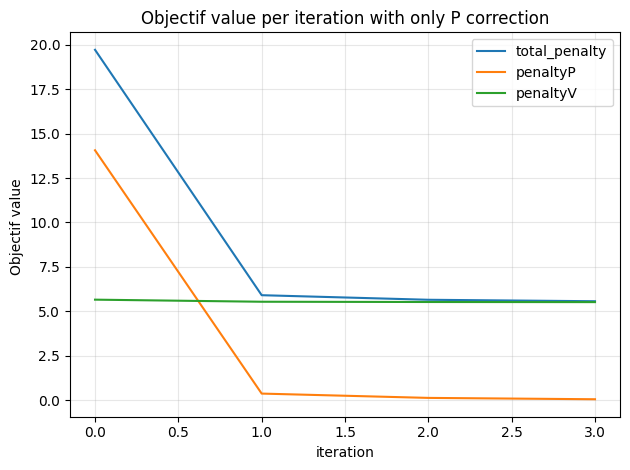

,total_penalty,penaltyP,penaltyQ,penaltyV,status
0,19.716704,14.061971,1.439954e-06,5.654731,-104
1,5.905651,0.368253,3.082110e-09,5.537398,0
2,5.648259,0.125670,4.672736e-06,5.522584,-104
3,5.566039,0.049613,2.496569e-09,5.516426,0


In [22]:
plt.figure(figsize=(8, 4))
optim_info[['total_penalty','penaltyP','penaltyV']].plot()
plt.title("Objectif value per iteration with only P correction")
plt.xlabel("iteration")
plt.ylabel("Objectif value ")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
optim_info